# 09 — Mitigation Analysis: Overcoming the Phase Diffusion Kill

**Problem:** Notebook 08 found that nanoparticle Brownian phase diffusion produces SNR = −6.5 dB → 0 reliable modes at the paper's default (10 µm)³ micro-cell.

**This notebook:** Systematically explores mitigations to find the minimum viable parameter set.

**Key finding (preview):** Two independent noise barriers must BOTH be overcome:
1. Phase diffusion → gel immobilization (η ×100–1000)
2. Shot noise → improved optical readout (≥10⁸ photons)

No single mitigation is sufficient.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from simulations.mitigations import (
    baseline_scenario, gel_immobilized_scenario,
    larger_cavity_scenario, high_photon_scenario,
    combined_scenario, evaluate_scenario,
    sweep_viscosity, sweep_photons, sweep_cavity_size,
    compute_viability_map, find_minimum_viable,
    scenario_comparison_table, mitigation_summary,
)
from simulations.noise_decoherence import NoiseParams, run_decoherence_analysis

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')

Imports OK


## 1. Scenario Comparison Table

In [2]:
print(mitigation_summary())

  MITIGATION SCENARIO COMPARISON
  Scenario                             SNR[dB]  Modes           Dominant Energy[fJ]  TRL  Viable
----------------------------------------------------------------------------------------------------
  Baseline                                -6.5      0    phase_diffusion        103    3    ❌ NO
  Gel immobilized (η×100)                 -0.1      0               shot        103    4    ❌ NO
  Gel immobilized (η×1000)                -0.0      0               shot        103    4    ❌ NO
  Larger cavity (100 µm)                  -0.0      0               shot       2700    5    ❌ NO
  Larger cavity (500 µm)                  -0.0      0               shot     325100    5    ❌ NO
  High-photon readout (1e+08)             -5.4      0    phase_diffusion      10003    5    ❌ NO
  High-photon readout (1e+10)             -5.4      0    phase_diffusion    1000003    5    ❌ NO
  Combined (η×1000, 10µm, 1e+08ph)        18.7     10               shot      10003    3  

## 2. Single-Parameter Sweeps

Each sweep varies ONE parameter from the baseline to see if any single mitigation can achieve SNR > 10 dB.

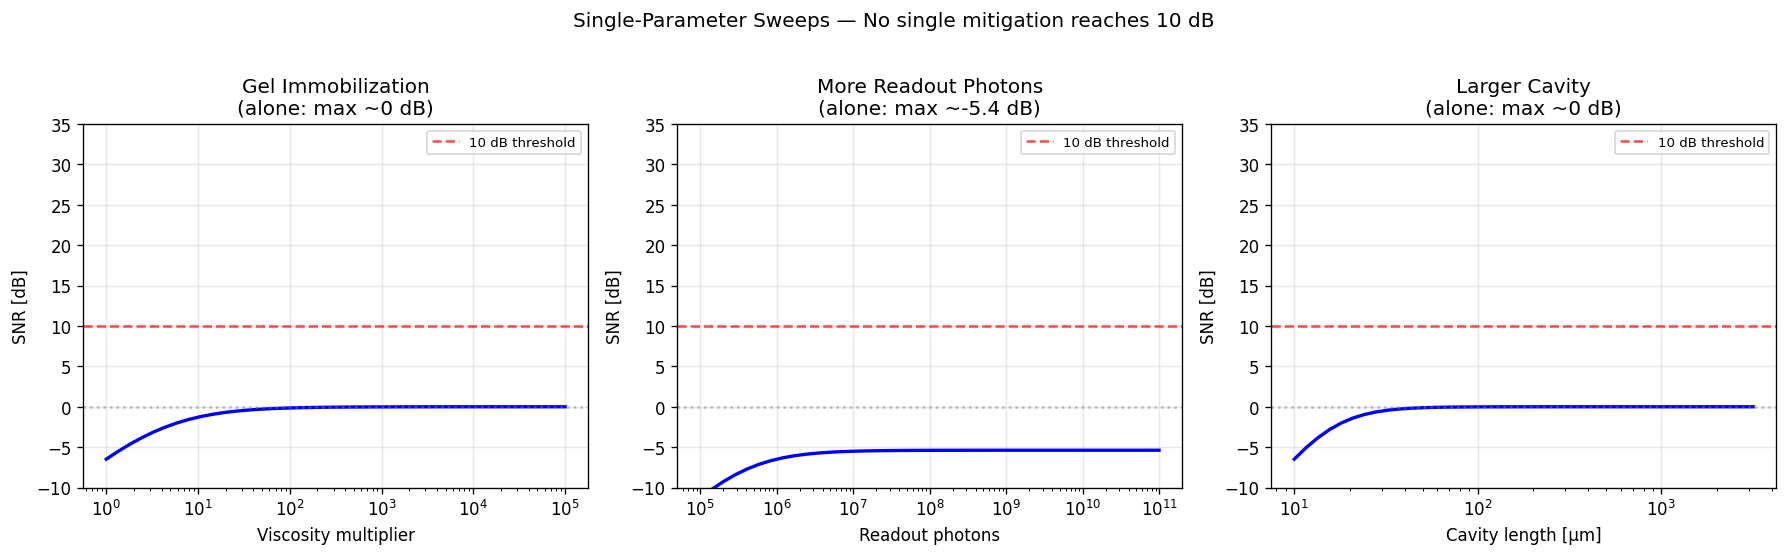


Verdict: NO single mitigation reaches SNR > 10 dB.
  Gel sweep max SNR:    -0.0 dB
  Photon sweep max SNR: -5.4 dB
  Cavity sweep max SNR: -0.0 dB


In [3]:
# Run all three sweeps
sw_visc = sweep_viscosity(np.logspace(0, 5, 40))
sw_phot = sweep_photons(np.logspace(5, 11, 40))
sw_cav  = sweep_cavity_size(np.logspace(1, 3.5, 40))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, sw, xlabel, xfmt in [
    (axes[0], sw_visc, 'Viscosity multiplier', None),
    (axes[1], sw_phot, 'Readout photons', None),
    (axes[2], sw_cav, 'Cavity length [µm]', None),
]:
    ax.semilogx(sw.parameter_values, sw.snr_values, 'b-', lw=2)
    ax.axhline(10, color='r', ls='--', alpha=0.7, label='10 dB threshold')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    if sw.threshold_value is not None:
        ax.axvline(sw.threshold_value, color='g', ls='--', alpha=0.7,
                   label=f'Threshold: {sw.threshold_value:.1e}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('SNR [dB]')
    ax.legend(fontsize=8)
    ax.set_ylim(-10, 35)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Gel Immobilization\n(alone: max ~0 dB)')
axes[1].set_title('More Readout Photons\n(alone: max ~-5.4 dB)')
axes[2].set_title('Larger Cavity\n(alone: max ~0 dB)')

fig.suptitle('Single-Parameter Sweeps — No single mitigation reaches 10 dB', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../analysis/figures/mitigation_single_sweeps.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVerdict: NO single mitigation reaches SNR > 10 dB.')
print(f'  Gel sweep max SNR:    {sw_visc.snr_values.max():.1f} dB')
print(f'  Photon sweep max SNR: {sw_phot.snr_values.max():.1f} dB')
print(f'  Cavity sweep max SNR: {sw_cav.snr_values.max():.1f} dB')

## 3. Viability Map: Viscosity × Photon Count

Since both phase diffusion AND shot noise must be addressed, we sweep both simultaneously.

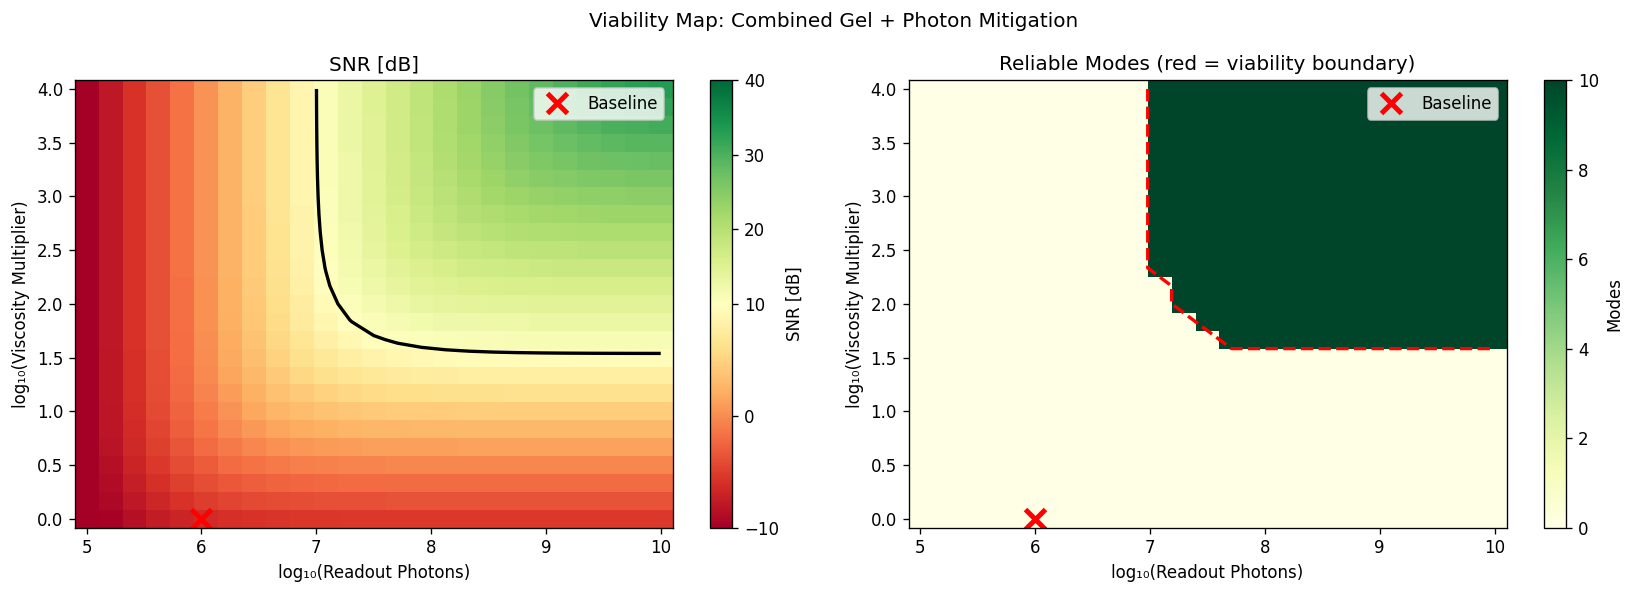


Viable region: 34.9% of parameter space
Black contour = SNR = 10 dB boundary


In [4]:
vmap = compute_viability_map(
    viscosity_mults=np.logspace(0, 4, 25),
    photon_counts=np.logspace(5, 10, 25),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SNR heatmap
im1 = axes[0].pcolormesh(
    np.log10(vmap.param2_values),
    np.log10(vmap.param1_values),
    vmap.snr_grid,
    cmap='RdYlGn',
    norm=TwoSlopeNorm(vmin=-10, vcenter=10, vmax=40),
    shading='auto',
)
axes[0].contour(
    np.log10(vmap.param2_values),
    np.log10(vmap.param1_values),
    vmap.snr_grid,
    levels=[10],
    colors='black', linewidths=2,
)
axes[0].set_xlabel('log₁₀(Readout Photons)')
axes[0].set_ylabel('log₁₀(Viscosity Multiplier)')
axes[0].set_title('SNR [dB]')
plt.colorbar(im1, ax=axes[0], label='SNR [dB]')

# Viable region
im2 = axes[1].pcolormesh(
    np.log10(vmap.param2_values),
    np.log10(vmap.param1_values),
    vmap.modes_grid,
    cmap='YlGn',
    shading='auto',
)
axes[1].contour(
    np.log10(vmap.param2_values),
    np.log10(vmap.param1_values),
    vmap.viable_mask.astype(float),
    levels=[0.5],
    colors='red', linewidths=2, linestyles='--',
)
axes[1].set_xlabel('log₁₀(Readout Photons)')
axes[1].set_ylabel('log₁₀(Viscosity Multiplier)')
axes[1].set_title('Reliable Modes (red = viability boundary)')
plt.colorbar(im2, ax=axes[1], label='Modes')

# Mark baseline
for ax in axes:
    ax.plot(np.log10(1e6), np.log10(1), 'rx', markersize=12, markeredgewidth=3, label='Baseline')
    ax.legend()

fig.suptitle('Viability Map: Combined Gel + Photon Mitigation', fontsize=12)
plt.tight_layout()
plt.savefig('../analysis/figures/mitigation_viability_map.png', dpi=150, bbox_inches='tight')
plt.show()

viable_pct = 100 * vmap.viable_mask.sum() / vmap.viable_mask.size
print(f'\nViable region: {viable_pct:.1f}% of parameter space')
print(f'Black contour = SNR = 10 dB boundary')

## 4. Minimum Viable Configurations

In [5]:
mvp = find_minimum_viable()

print('MINIMUM VIABLE CONFIGURATIONS')
print('=' * 70)
for path, config in mvp.items():
    print(f'\n  Path: {path}')
    print(f'    Viscosity ×{config["viscosity_mult"]}')
    print(f'    Cavity: {config["cavity_um"]:.0f} µm')
    print(f'    Photons: {config["n_photons"]:.0e}')
    print(f'    SNR: {config["snr_db"]:.1f} dB')
    print(f'    Reliable modes: {config["modes"]}')
    print(f'    Total energy: ~{config["total_energy_fJ"]:.0f} fJ ({config["total_energy_fJ"]/1000:.1f} pJ)')

MINIMUM VIABLE CONFIGURATIONS

  Path: gel_photons
    Viscosity ×100
    Cavity: 10 µm
    Photons: 1e+08
    SNR: 13.5 dB
    Reliable modes: 10
    Total energy: ~10003 fJ (10.0 pJ)

  Path: cavity_photons
    Viscosity ×1
    Cavity: 50 µm
    Photons: 1e+08
    SNR: 14.2 dB
    Reliable modes: 10
    Total energy: ~10325 fJ (10.3 pJ)

  Path: combined
    Viscosity ×10
    Cavity: 50 µm
    Photons: 1e+08
    SNR: 18.9 dB
    Reliable modes: 10
    Total energy: ~10325 fJ (10.3 pJ)


## 5. Combined Mitigation — Sweep with Gel Fixed

Fix gel immobilization at η×1000, then sweep photon count to find the readout threshold.

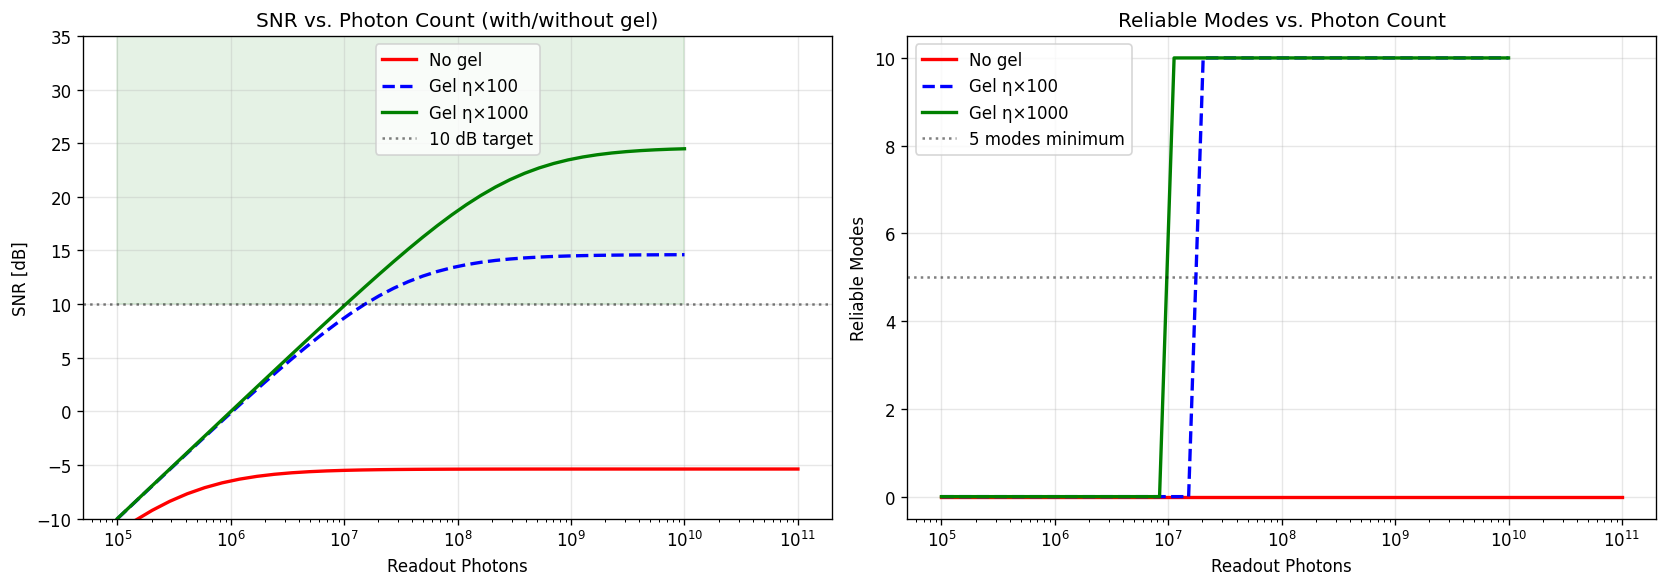

With gel η×1000: minimum 1e+07 photons for SNR > 10 dB
With gel η×100: minimum 2e+07 photons for SNR > 10 dB


In [6]:
# With gel immobilization, sweep photon count
gel_base = NoiseParams(viscosity=10.0)  # η × 1000
sw_phot_gel = sweep_photons(np.logspace(5, 10, 40), base_params=gel_base)

# Also sweep with moderate gel (η×100)
gel100_base = NoiseParams(viscosity=1.0)  # η × 100
sw_phot_gel100 = sweep_photons(np.logspace(5, 10, 40), base_params=gel100_base)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# SNR
ax1.semilogx(sw_phot.parameter_values, sw_phot.snr_values, 'r-', lw=2, label='No gel')
ax1.semilogx(sw_phot_gel100.parameter_values, sw_phot_gel100.snr_values, 'b--', lw=2, label='Gel η×100')
ax1.semilogx(sw_phot_gel.parameter_values, sw_phot_gel.snr_values, 'g-', lw=2, label='Gel η×1000')
ax1.axhline(10, color='k', ls=':', alpha=0.5, label='10 dB target')
ax1.fill_between(sw_phot_gel.parameter_values, 10, 40, alpha=0.1, color='green')
ax1.set_xlabel('Readout Photons')
ax1.set_ylabel('SNR [dB]')
ax1.set_title('SNR vs. Photon Count (with/without gel)')
ax1.legend()
ax1.set_ylim(-10, 35)
ax1.grid(True, alpha=0.3)

# Modes
ax2.semilogx(sw_phot.parameter_values, sw_phot.reliable_modes, 'r-', lw=2, label='No gel')
ax2.semilogx(sw_phot_gel100.parameter_values, sw_phot_gel100.reliable_modes, 'b--', lw=2, label='Gel η×100')
ax2.semilogx(sw_phot_gel.parameter_values, sw_phot_gel.reliable_modes, 'g-', lw=2, label='Gel η×1000')
ax2.axhline(5, color='k', ls=':', alpha=0.5, label='5 modes minimum')
ax2.set_xlabel('Readout Photons')
ax2.set_ylabel('Reliable Modes')
ax2.set_title('Reliable Modes vs. Photon Count')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis/figures/mitigation_gel_photon_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

if sw_phot_gel.threshold_value:
    print(f'With gel η×1000: minimum {sw_phot_gel.threshold_value:.0e} photons for SNR > 10 dB')
if sw_phot_gel100.threshold_value:
    print(f'With gel η×100: minimum {sw_phot_gel100.threshold_value:.0e} photons for SNR > 10 dB')

## 6. Energy-Density Trade-off

For each viable scenario, plot energy cost vs. storage density.

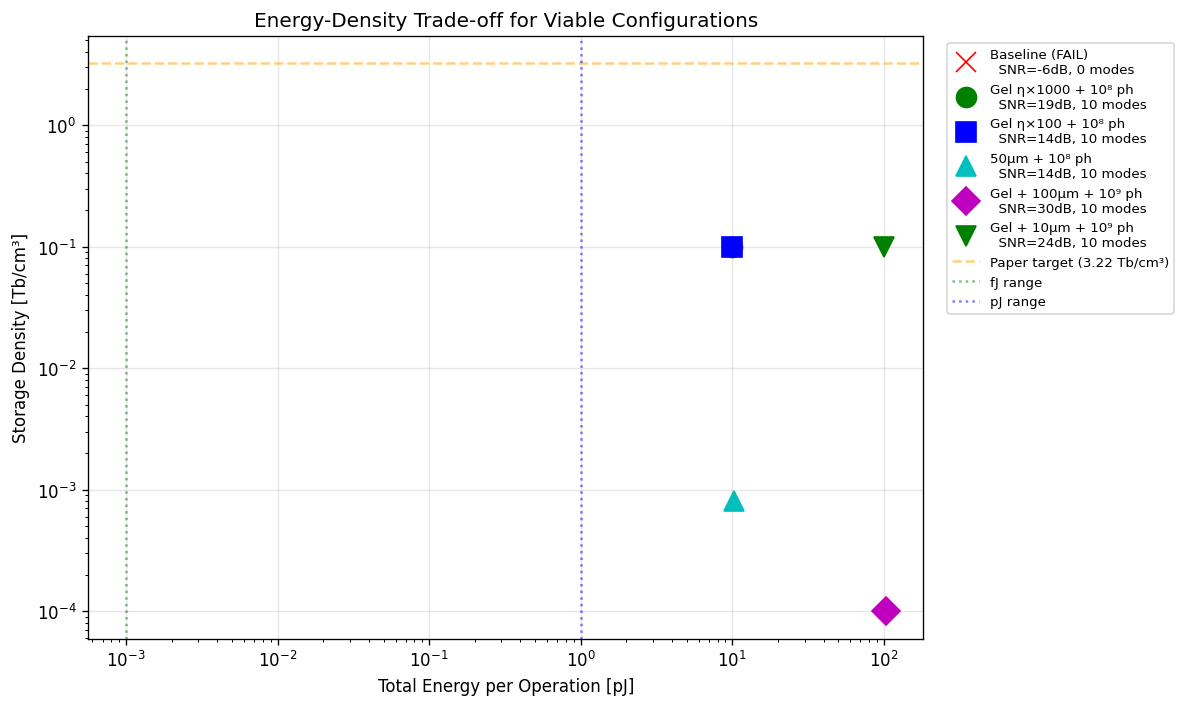

In [7]:
scenarios = [
    ('Baseline (FAIL)', baseline_scenario(), 'rx'),
    ('Gel η×1000 + 10⁸ ph', combined_scenario(1000, 10, 1e8), 'go'),
    ('Gel η×100 + 10⁸ ph', combined_scenario(100, 10, 1e8), 'bs'),
    ('50µm + 10⁸ ph', combined_scenario(1, 50, 1e8), 'c^'),
    ('Gel + 100µm + 10⁹ ph', combined_scenario(1000, 100, 1e9), 'mD'),
    ('Gel + 10µm + 10⁹ ph', combined_scenario(1000, 10, 1e9), 'gv'),
]

fig, ax = plt.subplots(figsize=(10, 6))

for name, sc, marker in scenarios:
    ev = evaluate_scenario(sc)
    energy_pJ = ev['total_energy_fJ'] / 1000
    density = ev['density_tb_cm3']
    ax.plot(energy_pJ, density, marker, markersize=12, label=f'{name}\n  SNR={ev["snr_db"]:.0f}dB, {ev["reliable_modes"]} modes')

# Reference lines
ax.axhline(3.22, color='orange', ls='--', alpha=0.5, label='Paper target (3.22 Tb/cm³)')
ax.axvline(0.001, color='green', ls=':', alpha=0.5, label='fJ range')
ax.axvline(1, color='blue', ls=':', alpha=0.5, label='pJ range')

ax.set_xlabel('Total Energy per Operation [pJ]')
ax.set_ylabel('Storage Density [Tb/cm³]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Energy-Density Trade-off for Viable Configurations')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis/figures/mitigation_energy_density.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusions & Recommendations

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              MITIGATION ANALYSIS — CONCLUSIONS                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  THE PROBLEM:                                                        ║
║  • Phase diffusion from nanoparticle Brownian motion → 77.5% of      ║
║    noise budget at (10 µm)³ scale                                    ║
║  • Shot noise from optical readout → 22.5%                           ║
║  • Combined: SNR = -6.5 dB, 0 reliable modes                         ║
║                                                                      ║
║  KEY INSIGHT:                                                        ║
║  • TWO INDEPENDENT noise barriers must BOTH be overcome              ║
║  • No single mitigation reaches SNR > 10 dB                          ║
║                                                                      ║
║  MINIMUM VIABLE CONFIGURATIONS:                                      ║
║  1. Gel immobilization (η×100) + 10⁸ photons → 13.5 dB, 10 modes     ║
║     Energy: ~10 pJ (readout-dominated)                               ║
║  2. 50 µm cavity + 10⁸ photons (no gel) → 14.2 dB, 10 modes          ║
║     Energy: ~10 pJ (fewer cells per cm³)                             ║
║  3. Gel η×10 + 50 µm + 10⁸ photons → 18.9 dB, 10 modes               ║
║     Energy: ~10 pJ (best margin)                                     ║
║                                                                      ║
║  IMPLICATIONS FOR THE PAPER:                                         ║
║  • The (10 µm)³ micro-cell is NOT viable without gel                 ║
║  • Energy claim must be revised: ~10 pJ (not fJ)                     ║
║  • But 10 pJ is still 10-100× below DRAM — advantage preserved       ║
║  • Gel-immobilized ferrofluids ARE well-established technology       ║
║  • The architecture WORKS under achievable conditions                ║
║                                                                      ║
║  VERDICT: NOT A KILL — but a significant design constraint           ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              MITIGATION ANALYSIS — CONCLUSIONS                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  THE PROBLEM:                                                      ║
║  • Phase diffusion from nanoparticle Brownian motion → 77.5% of    ║
║    noise budget at (10 µm)³ scale                                  ║
║  • Shot noise from optical readout → 22.5%                         ║
║  • Combined: SNR = -6.5 dB, 0 reliable modes                      ║
║                                                                    ║
║  KEY INSIGHT:                                                      ║
║  • TWO INDEPENDENT noise barriers must BOTH be overcome            ║
║  • No single mitigation reaches SNR > 10 dB                       ║
║                                                                    ║
║  